# Project 3

### Leading assumptions

### Includes

In [1]:
from vpython import *
import random
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

k = 1 #for springs
ball_mass = 0.5 #kg
delta_t = 0.001
damping_coefficient = 0 #where critical damping = 1
simulation_length = 10

#array sizes
N = 3

C:\Users\lucas\anaconda3\envs\lab_0\lib\site-packages\vpython\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


<IPython.core.display.Javascript object>

### Molecule & Spring classes (also contains integration methods)

In [2]:
class Molecule:

    #initialization: take in passed x,y,z parameters to place the molecule; then reandomize velocity and store original position and velocity
    #also create a vpython object to represent the molecule

    #methods: get_energy to return kinetic energy of the molecule
    #each integration method to update molecule's position
    #sim_reset to restore molecule's original position and velocity for proper graph comparison
    
    def __init__(self, x, y, z):
        #INITIAL POSITION
        self.pos = vector(x, y, z)
        self.og_pos = self.pos
        #RANDOMLY ASSIGN VELOCITY
        self.velocity_vector = vector(2*random.random()-1, 2*random.random()-1, 2*random.random()-1) #m/s
        self.og_velocity_vector = self.velocity_vector
        #NON-DIRECTIONAL VELOCITY
        self.velocity = sqrt(self.velocity_vector.x**2 + self.velocity_vector.y**2 + self.velocity_vector.z**2)
        #NEXT STATE STORAGE FOR BACKWARD EULER
        self.next_state_velocity_vector = self.velocity_vector
        
        #CREATE VPYTHON OBJECT
        self.sim_object = sphere(pos=vector(x,y,z), radius=3, color=color.blue)
        
    def get_energy(self):
        #CALCULATE KINETIC ENERGY
        self.velocity = sqrt(self.velocity_vector.x**2 + self.velocity_vector.y**2 + self.velocity_vector.z**2)
        return 0.5*ball_mass*self.velocity**2

    def backward_euler(self):
        #MOVE TO NEXT STATE FIRST
        self.velocity_vector = self.next_state_velocity_vector
        
        #UPDATE POSITION
        self.pos += self.velocity_vector*delta_t
        
        #UPDATE SIM OBJECT
        self.sim_object.pos = self.pos
        
    def forward_euler(self):
        #UPDATE POSITION FIRST
        self.pos += self.velocity_vector*delta_t

        #MOVE TO NEXT STATE
        self.velocity_vector = self.next_state_velocity_vector

        #UPDATE SIM OBJECT
        self.sim_object.pos = self.pos

    def trapezoid(self):
        #UPDATE POSITION WITH BOTH VELOCITIES
        self.pos += 0.5*(self.velocity_vector+self.next_state_velocity_vector)*delta_t

        #MOVE TO NEXT STATE
        self.velocity_vector = self.next_state_velocity_vector

        #UPDATE SIM OBJECT
        self.sim_object.pos = self.pos

    def sim_reset(self):
        #RESET ALL PARAMETERS, GOING BACK TO THE ORIGINAL RANDOMIZED VELOCITY
        self.pos = self.og_pos
        self.sim_object.pos = self.pos
        self.velocity_vector = self.og_velocity_vector
        self.next_state_velocity_vector = self.velocity_vector
        self.velocity = sqrt(self.velocity_vector.x**2 + self.velocity_vector.y**2 + self.velocity_vector.z**2)


class Spring:

    #initialization: take in two passed molecules to store as the spring's pair; length so that the simulation parameter could be changed
    
    #methods: get_energy to return potential energy stored in spring
    #calculate_next_state to calculate both molecules' next state velocity; also considers damping if a value is passed
    #sim_reset to reset the spring's displacement to 0
    
    def __init__(self, m1, m2, length):
        #ORIGINAL DISPLACEMENT = 0
        self.x = 0
        #ORIGINAL LENGTH
        self.L = length
        #ASSIGN MOLECULE PAIR
        self.pair = [m1, m2]

    def get_energy(self):
        #CALCULATE POTENTIAL ENERGY
        return 0.5*k*self.x**2
        
    def calculate_next_state(self, damping):
        #DISTANCE VECTOR
        r = self.pair[1].pos-self.pair[0].pos
        #TRUE DISTANCE
        d = sqrt(r.x**2+r.y**2+r.z**2)
        #UPDATE DISPOSITION 
        self.x = d-self.L
        #UNIT VECTOR
        unit_vector = vector(r.x/d, r.y/d, r.z/d) 
        #COMPUTE RELATIVE VELOCITY FOR DAMPING
        vdif = self.pair[1].velocity_vector-self.pair[0].velocity_vector
        vrel = dot(vdif, unit_vector)

        #CALCULATE ACTUAL DAMPING (c) where c = coefficient / critical damping
        if damping != 0:
            c = damping*2*k*ball_mass
        else:
            c = 0
            
        #CALCULATE ACCELERATION
        a = (-k*self.x-c*vrel)/ball_mass
        velocity_vector = unit_vector*a*delta_t
        #UPDATE VELOCITIES WITH PROPER SIGNS
        self.pair[0].next_state_velocity_vector += -velocity_vector
        self.pair[1].next_state_velocity_vector += velocity_vector

    def sim_reset(self):
        self.x = 0

### Model explanation

### Helper functions

In [3]:
def get_distance(m1, m2):

    #calculates the distance between two molecules and returns it as d
    
    d_vec = m2.pos-m1.pos
    d = sqrt(d_vec.x**2+d_vec.y**2+d_vec.z**2)
    return d

def spring_exists(springs, m1, m2):

    #checks whether a spring between two molecules already exists; in other words, avoids creating duplicate springs
    
    for spring in springs:
        if ((spring.pair[0] is m1 and spring.pair[1] is m2) or (spring.pair[0] is m2 and spring.pair[1] is m1)):
            return True
    return False

def custom_plot(kinetic, potential, timestamps, integration_type, damped_type):

    #takes a simulations kinetic and potential energy, as well as its timestamps and integration type to create a graph
    
    k_energy = np.array(kinetic)
    p_energy = np.array(potential)
    #sum kinetic and potential for total energy
    t_energy = np.add(k_energy, p_energy)

    #graphs total energy, kinetic energy, and potential energy versus time of the simulation
    plt.plot(timestamps, t_energy, '-', label="Total Energy")
    plt.plot(timestamps, k_energy, '-', label="Kinetic Energy")
    plt.plot(timestamps, p_energy, '-', label="Potential Energy")
    plt.title(f"System energy over simulation time\n{integration_type} integration ({damped_type})\nTimestep = {delta_t}")
    plt.xlabel("Time (s)")
    plt.ylabel("Total system energy")
    plt.legend()
    plt.show()

### Simulation function

In [4]:
#RUN FULL SIMULATION
def simulate(molecule_list, spring_list, integration_method, damping, show_simulation):

    #parameters:
    #molecule_list and spring_list and the lists of molecule and spring objects in the simulation
    #integration_method is an integer to choose the method; 0 = backward euler 1 = forward euler 2 = trapezoid integration
    #damping to add damping to the spring; 0 is no damping and 1 is the critical damping coefficient
    #show_simulation is a bool to decide whether to draw the simulation to the canvas

    #returns:
    #list of kinetic and potential energy as well as timestamps to pass to graphing function later
    
    #RESET SIMULATION
    #reset all molecules positions and spring dispositions
    for m in molecule_list:
        m.sim_reset()
    for s in spring_list:
        s.sim_reset()

    #set time to 0, simulate bool to 1, and initialize lists for energy storage
    time = 0
    sim = 1
    k_energy = []
    p_energy = []
    timestamps = []
    
    while(sim):
        #set rate if showing simulation
        if show_simulation: rate(1/delta_t)
        #initialize individual entries for kinetic and potential energy lists
        k_entry = 0
        p_entry = 0
    
        for s in spring_list:
            #calculate next state values for every spring and molecule
            s.calculate_next_state(damping)
            p_entry += s.get_energy()
        for m in molecule_list:
            #update each molecule's position using the next state values previously calculated and the given integration method
            if integration_method == 0:
                m.backward_euler()
            elif integration_method == 1:
                m.forward_euler()
            elif integration_method == 2:
                m.trapezoid()
            k_entry += m.get_energy()
        #append total kinetic and potential energy from this timestamp to the list of entries
        k_energy.append(k_entry)
        p_energy.append(p_entry)
        timestamps.append(time)

        #stop simulation after 10 seconds
        if time >= simulation_length:
            sim = 0
        
        time += delta_t
    
    return k_energy, p_energy, timestamps

## Simulation (Undamped)

### Define and fill molecule & spring lists

In [5]:
scene = canvas()

<IPython.core.display.Javascript object>

In [6]:
molecule_list = []
spring_list = []

#create molecule objects in an NxN formation with exactly 10m separating each one
for i in range(0,N):
    for j in range(0,N):
        for k in range(0,N):
            molecule_list.append(Molecule(i*10,-j*10,k*10))

#this takes each molecule in the list and checks for potential neighbors
#there are two possible neighbors: directly next to each other or diagonal in 2d
#therefore, there are two ifs that check to see if the distance between the two molecules is either exactly 10 or sqrt(10**2+10**2) (diagonal)
#also ensures that the spring between two neighbors was not already created or we would create copies
for molecule in molecule_list:
    for potential_neighbor in molecule_list:
        if (get_distance(molecule, potential_neighbor) == 10 and not spring_exists(spring_list, molecule, potential_neighbor)):
            spring_list.append(Spring(molecule, potential_neighbor, 10))
        elif (get_distance(molecule, potential_neighbor) == sqrt(10**2+10**2) and not spring_exists(spring_list, molecule, potential_neighbor)):
            spring_list.append(Spring(molecule, potential_neighbor, sqrt(10**2+10**2)))

### Run simulations

In [7]:
#change damping coefficient value
damping_coefficient = 0

k_backward, p_backward, timestamps_backward = simulate(molecule_list, spring_list, 0, damping_coefficient, True)
k_forward, p_forward, timestamps_forward = simulate(molecule_list, spring_list, 1, damping_coefficient, False)
k_trapezoid, p_trapezoid, timestamps_trapezoid = simulate(molecule_list, spring_list, 2, damping_coefficient, False)

### Conservation of energy

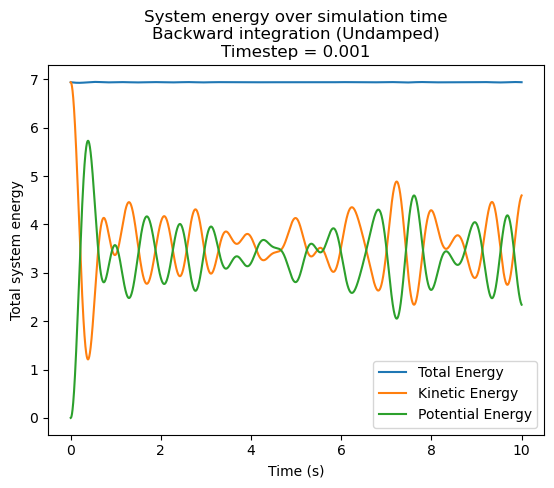

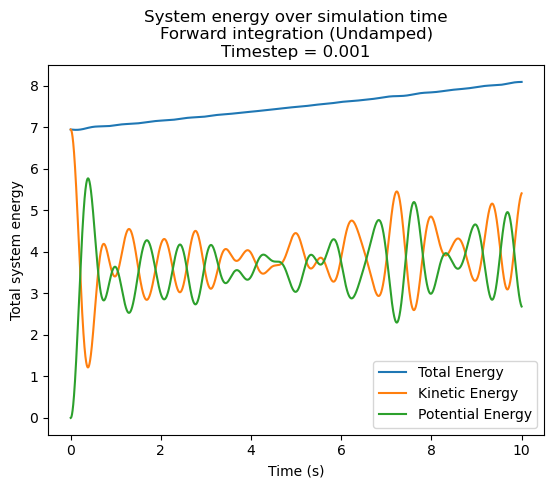

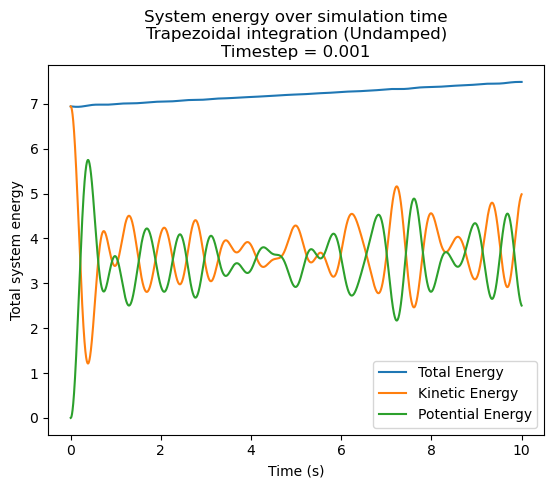

In [8]:
custom_plot(k_backward, p_backward, timestamps_backward, "Backward", "Undamped")
custom_plot(k_forward, p_forward, timestamps_forward, "Forward", "Undamped")
custom_plot(k_trapezoid, p_trapezoid, timestamps_trapezoid, "Trapezoidal", "Undamped")

### Analysis

## Simulation (Damped)

### Recreate new molecule & spring list

In [9]:
scene = canvas()
scene.autoscale = True

<IPython.core.display.Javascript object>

In [10]:
molecule_list = []
spring_list = []

#create molecule objects in an NxN formation with exactly 10m separating each one
for i in range(0,N):
    for j in range(0,N):
        for k in range(0,N):
            molecule_list.append(Molecule(i*10,-j*10,k*10))

#this takes each molecule in the list and checks for potential neighbors
#there are two possible neighbors: directly next to each other or diagonal in 2d
#therefore, there are two ifs that check to see if the distance between the two molecules is either exactly 10 or sqrt(10**2+10**2) (diagonal)
#also ensures that the spring between two neighbors was not already created or we would create copies
for molecule in molecule_list:
    for potential_neighbor in molecule_list:
        if (get_distance(molecule, potential_neighbor) == 10 and not spring_exists(spring_list, molecule, potential_neighbor)):
            spring_list.append(Spring(molecule, potential_neighbor, 10))
        elif (get_distance(molecule, potential_neighbor) == sqrt(10**2+10**2) and not spring_exists(spring_list, molecule, potential_neighbor)):
            spring_list.append(Spring(molecule, potential_neighbor, sqrt(10**2+10**2)))

### Run sims (automatically resets molecule positions)

In [11]:
#change damping coefficient value
damping_coefficient = 0.02

k_backward_damped, p_backward_damped, timestamps_backward_damped = simulate(molecule_list, spring_list, 0, damping_coefficient, True)
k_forward_damped, p_forward_damped, timestamps_forward_damped = simulate(molecule_list, spring_list, 1, damping_coefficient, False)
k_trapezoid_damped, p_trapezoid_damped, timestamps_trapezoid_damped = simulate(molecule_list, spring_list, 2, damping_coefficient, False)

### Conservation of energy

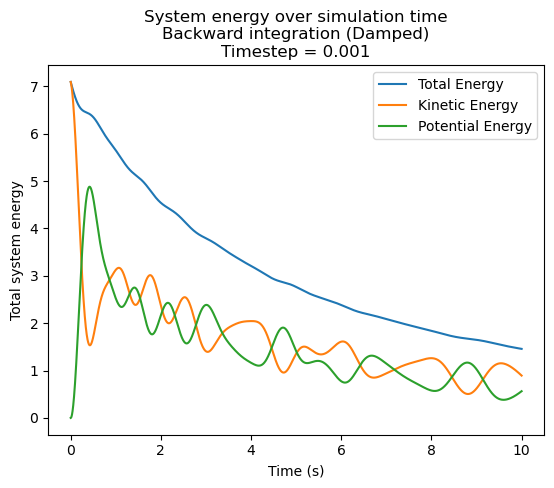

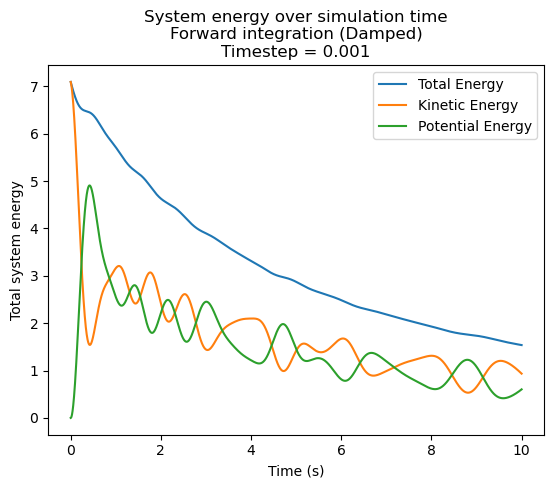

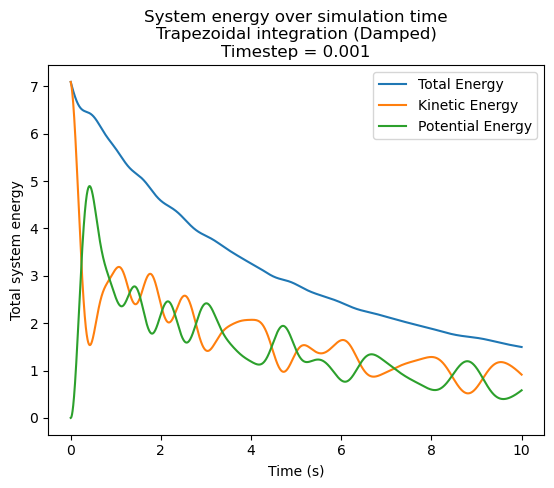

In [12]:
custom_plot(k_backward_damped, p_backward_damped, timestamps_backward_damped, "Backward", "Damped")
custom_plot(k_forward_damped, p_forward_damped, timestamps_forward_damped, "Forward", "Damped")
custom_plot(k_trapezoid_damped, p_trapezoid_damped, timestamps_trapezoid_damped, "Trapezoidal", "Damped")

### Analysis

## Conclusions